# Airbnb Bookings Analysis

# **Problem Statements -**

1. Which neighborhoods in New York City are the most popular for Airbnb rentals, and how do prices and availability change depending on the neighborhood?

2. How has the Airbnb rental scene in New York City changed over time? Have there been any big changes in the number of places to stay, prices, or how often they're booked?

3. Are there any trends in the types of places people rent out on Airbnb in New York City? Do certain types of places get more bookings or cost more than others?

4. What things affect how much Airbnb rentals cost in New York City?

5. Where's the best place in New York City for someone who wants to rent out a property at a good price and in a busy area?

6. Do people tend to stay for different lengths of time in Airbnb rentals depending on which neighborhood they're in? Are some neighborhoods better for shorter or longer stays?

7. Do Airbnb rentals in New York City with higher prices usually have better ratings? Or is there no connection between price and rating?

8. How many reviews does each neighborhood group in New York City get, and what's the most reviews any of them has gotten?

9. What type of room gets reviewed the most in each neighborhood group in New York City each month?

10. Where's the best place to stay in New York City for someone visiting?

11. Where's the best place in New York City for someone who wants to rent out a property?

12. How do prices for Airbnb rentals vary in different neighborhood groups in New York City?York City?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data=pd.read_csv(r"/content/Airbnb NYC 2019.csv")

##**About the Dataset – Airbnb Bookings**

* This Airbnb dataset contains nearly 49,000 observations from New York , with 16 columns of data.

* The Data includes both categorical and numeric values, providing a diverse range of information about the listings.

* This Dataset may be useful for analyzing trends and patterns in the Airbnb market in New York and also gain insights into the preferences and behavior of Airbnb users in the area.

* This dataset contains information about Airbnb bookings in New York City in 2019. By analyzing this data, you may be able to understand the trends and patterns of Airbnb use in the NYC

#**THE GIVEN VARIABLES**

**Listing_id :-** This is a unique identifier for each listing in the dataset.

**Listing_name :-** This is the name or title of the listing, as it appears on the Airbnb website.

**Host_id :-** This is a unique identifier for each host in the dataset.

**Host_name :-** This is the name of the host as it appears on the Airbnb website.

**Neighbourhood_group :-** This is a grouping of neighborhoods in New York City, such as Manhattan or Brooklyn.

**Neighbourhood :-** This is the specific neighborhood in which the listing is located.

**Latitude :-** This is the geographic latitude of the listing.

**Longitude :-** This is the geographic longitude of the listing.

**Room_type :-** This is the type of room or property being offered, such as an entire home, private room, shared room.

**Price :-** This is the nightly price for the listing, in US dollars.

**Minimum_nights :-** This is the minimum number of nights that a guest must stay at the listing.

**Total_reviews :-** This is the total number of reviews that the listing has received.

**Reviews_per_month :-** This is the average number of reviews that the listing receives per month.

**Host_listings_count :-** This is the total number of listings that the host has on Airbnb.

**Availability_365 :-** This is the number of days in the next 365 days that the listing is available for booking.

In [4]:
data.shape

(48895, 16)

# Data Cleaning

In [5]:
data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
rename_col = {'id':'listing_id','name':'listing_name','number_of_reviews':'total_reviews','calculated_host_listings_count':'host_listings_count'}

In [7]:
data = data.rename(columns = rename_col)
data.head(5)

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,last_review,reviews_per_month,host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           48895 non-null  int64  
 1   listing_name         48879 non-null  object 
 2   host_id              48895 non-null  int64  
 3   host_name            48874 non-null  object 
 4   neighbourhood_group  48895 non-null  object 
 5   neighbourhood        48895 non-null  object 
 6   latitude             48895 non-null  float64
 7   longitude            48895 non-null  float64
 8   room_type            48895 non-null  object 
 9   price                48895 non-null  int64  
 10  minimum_nights       48895 non-null  int64  
 11  total_reviews        48895 non-null  int64  
 12  last_review          38843 non-null  object 
 13  reviews_per_month    38843 non-null  float64
 14  host_listings_count  48895 non-null  int64  
 15  availability_365     48895 non-null 

**Things like host name, neighborhood group, neighborhood, and room type are types of information that fall into categories.**

On the other hand, details like host ID, latitude, longitude, price, minimum nights, number of reviews, last review, reviews per month, host listings count, and availability throughout the year are all numbers or quantities.

In [9]:
data[data.duplicated()]

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,last_review,reviews_per_month,host_listings_count,availability_365


In [10]:
data.isnull().sum()

,0
listing_id,0
listing_name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


We don't have too many missing values for host_name and listing_name, so we can start by filling them in with some other names for now.

In [11]:
data['listing_name'].fillna('unknown',inplace=True)
data['host_name'].fillna('no_name',inplace=True)

We have 10,052 empty spots in the **last_review** and **reviews_per_month** columns. We don't need the **last_review** column because we have other columns, like **number_of_reviews**and **reviews_per_month** that give us similar info. So, we're okay with getting rid of that one.

As for the **listing_id** column, it's not super crucial for our analysis. However, since **listing_id** and **listing_name** usually go together, we're keeping it around.

The **reviews_per_month** column also containing null values and we can simple put 0 reviews by replacing NAN's
i think this is make sense -

In [12]:
data = data.drop(['last_review'], axis=1)

In [13]:
data['reviews_per_month'] = data['reviews_per_month'].replace(to_replace=np.nan,value=0).astype('int64')

In [14]:
data.isnull().sum()

,0
listing_id,0
listing_name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


# Unique Value for variables

In [15]:
data['listing_name'].nunique()

47906

Most of the listing/property are different in Dataset

In [16]:
data['host_name'].nunique()

11453

Total 11453 different hosts in Airbnb-NYC

In [17]:
data['neighbourhood_group'].nunique()

5

Total 5 unique neighborhood_group in Dataset

In [18]:
data[data['host_name']=='David']['listing_name'].nunique()

402

Here same host David operates different 402 listing/property

In [19]:
data[data['listing_name']==data['host_name']]

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,reviews_per_month,host_listings_count,availability_365
9473,7264659,Olivier,6994503,Olivier,Manhattan,Upper West Side,40.78931,-73.97520,Entire home/apt,200,5,12,0,1,25
10682,8212051,Monty,43302952,Monty,Brooklyn,East Flatbush,40.66383,-73.92706,Shared room,95,2,7,0,1,238
16422,13186374,Sean,35143476,Sean,Brooklyn,Windsor Terrace,40.65182,-73.98043,Entire home/apt,400,7,0,0,1,0
23996,19348168,Cyn,74033595,Cyn,Brooklyn,Bedford-Stuyvesant,40.67850,-73.91478,Private room,75,2,1,0,1,0
24152,19456810,Hillside Hotel,134184451,Hillside Hotel,Queens,Briarwood,40.70454,-73.81549,Private room,93,1,2,0,18,90
24607,19785737,Hillside Hotel,134184451,Hillside Hotel,Queens,Jamaica,40.70445,-73.81399,Private room,135,1,1,0,18,180
26734,21231543,Hillside Hotel,134184451,Hillside Hotel,Queens,Jamaica,40.70428,-73.81353,Private room,135,1,0,0,18,365
26752,21243952,Hillside Hotel,134184451,Hillside Hotel,Queens,Jamaica,40.70288,-73.81531,Private room,135,1,1,0,18,365
26753,21244035,Hillside Hotel,134184451,Hillside Hotel,Queens,Jamaica,40.70319,-73.81410,Private room,135,1,2,0,18,365
26889,21311903,Hillside Hotel,134184451,Hillside Hotel,Queens,Jamaica,40.70258,-73.81510,Private room,135,1,0,0,18,365


In [20]:
data.loc[(data['neighbourhood_group']=='Queens') & (data['host_name']=='Alex')].head(4)

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,reviews_per_month,host_listings_count,availability_365
3523,2104910,SPACIOUS APT BK/QUEENS w/BACKYARD!,10643810,Alex,Queens,Ridgewood,40.70988,-73.90845,Entire home/apt,99,2,57,0,1,42
4512,3116519,Large 900 sqft Artist's Apartment,3008690,Alex,Queens,Ridgewood,40.70124,-73.90941,Entire home/apt,70,10,0,0,1,0
6178,4518242,Zen MiniPalace Astoria,23424461,Alex,Queens,Astoria,40.76369,-73.91601,Entire home/apt,80,1,3,0,1,0
10543,8090529,"Modern studio in Queens, NY",17377835,Alex,Queens,Sunnyside,40.74674,-73.91881,Entire home/apt,250,3,0,0,1,364


Same host have hosted different listing/property in different or same neighbourhood in same neighbourhood groups

# Describe the Dataset and removing outliers

In [21]:
data.describe()

,listing_id,host_id,latitude,longitude,price,minimum_nights,total_reviews,reviews_per_month,host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,0.806258,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.502767,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.000000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.000000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.000000,327.000000,365.000000


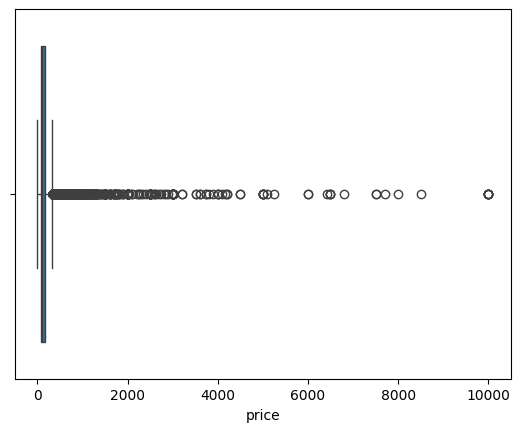

In [22]:
sns.boxplot(x=data['price'])
plt.show()

In [23]:
def iqr_technique(DFcolumn):
  Q1 = np.percentile(DFcolumn, 25)
  Q3 = np.percentile(DFcolumn, 75)
  IQR = Q3 - Q1
  lower_range = Q1 - (1.5 * IQR)
  upper_range = Q3 + (1.5 * IQR)                        # interquantile range

  return lower_range,upper_range

In [24]:
lower_bound,upper_bound = iqr_technique(data['price'])

data = data[(data.price>lower_bound) & (data.price<upper_bound)]

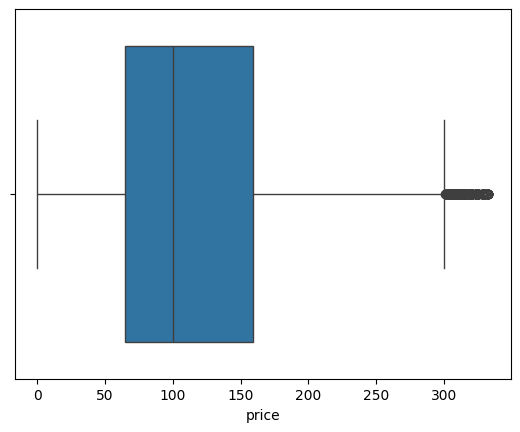

In [25]:
sns.boxplot(x = data['price'])
plt.show()

In [26]:
data.shape

(45918, 15)

# Data Visualization

 **(1) Distribution Of Airbnb Bookings Price Range Using Histogram**

Text(0.5, 1.0, 'Distribution of Airbnb Prices')

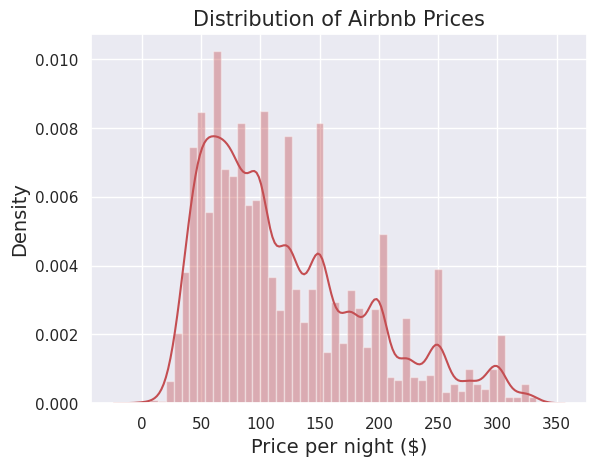

In [27]:
sns.set_theme(style='darkgrid')
sns.distplot(data['price'],color=('r'))
plt.xlabel('Price per night ($)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Distribution of Airbnb Prices',fontsize=15)

*   The range of prices being charged on Airbnb appears to be from **20 to 330 dollars** , with the majority of listings falling in the price range of **50 to 150 dollars.**

*   The distribution of prices appears to have a peak in the **50 to 150 dollars range**, with a relatively lower density of listings in higher and lower price ranges.

*   There may be fewer listings available at prices above **250 dollars**, as
the density of listings drops significantly in this range.

   **(2) Total Listing/Property count in Each Neighborhood Group using Count plot**

In [28]:
counts = data['neighbourhood_group'].value_counts()
Top_Neighborhood_group = counts.reset_index()
Top_Neighborhood_group.columns = ['Neighborhood_Groups', 'Listing_Counts']
Top_Neighborhood_group

,Neighborhood_Groups,Listing_Counts
0,Manhattan,19501
1,Brooklyn,19415
2,Queens,5567
3,Bronx,1070
4,Staten Island,365


Text(0, 0.5, 'Total listings counts')

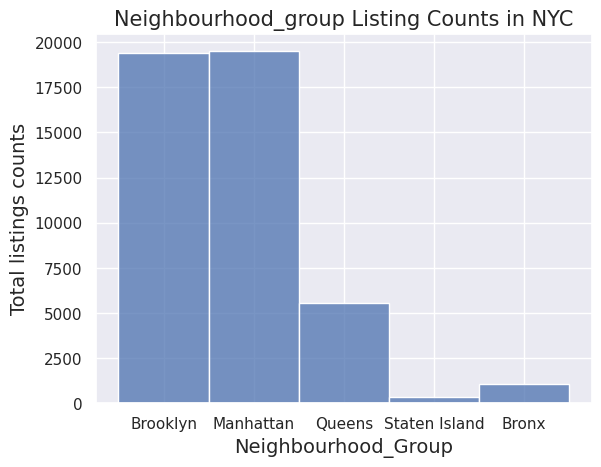

In [29]:
sns.histplot(data['neighbourhood_group'])
plt.title('Neighbourhood_group Listing Counts in NYC', fontsize=15)
plt.xlabel('Neighbourhood_Group', fontsize=14)
plt.ylabel('Total listings counts', fontsize=14)

* Most Airbnb listings are in Manhattan and Brooklyn, with over 19,000 each.
* Queens and the Bronx have fewer listings, around 5,567 and 1,070 respectively.
* Staten Island has the least, only 365.
* More listings are in Manhattan and Brooklyn than in Queens, the Bronx, and Staten Island combined.
* Maybe more people want Airbnb in Manhattan, so there are more listings there.
* Or maybe there are just more people willing to rent out their places in Manhattan.

**(3) Average Price Of Each Neighborhood Group using Point Plot**

In [30]:
grouped = data.groupby('neighbourhood_group')['price'].mean()
neighbourhood_group_avg_price = grouped.reset_index()
neighbourhood_group_avg_price = round(neighbourhood_group_avg_price.rename(columns={"price": "avg_price"}),2)
neighbourhood_group_avg_price[['neighbourhood_group', 'avg_price']].head()

,neighbourhood_group,avg_price
0,Bronx,77.37
1,Brooklyn,105.70
2,Manhattan,145.90
3,Queens,88.90
4,Staten Island,89.24


Text(0.5, 1.0, 'Average Price by Neighbourhood Group')

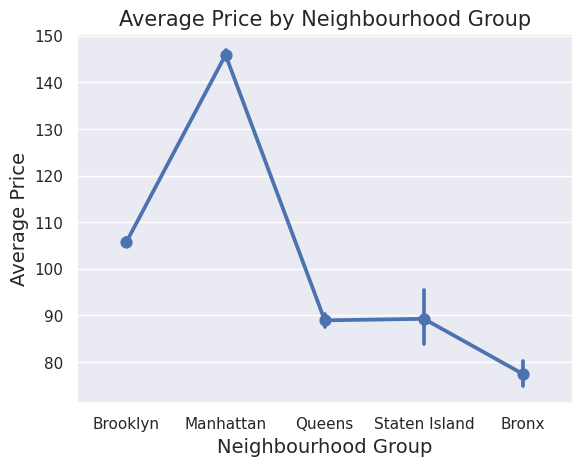

In [31]:
sns.pointplot(x = 'neighbourhood_group', y='price', data=data)

# Add axis labels and a title
plt.xlabel('Neighbourhood Group',fontsize=14)
plt.ylabel('Average Price',fontsize=14)
plt.title('Average Price by Neighbourhood Group',fontsize=15)

* Manhattan stands out with the highest average daily rental price at $146, while the Bronx has the lowest at around $77.
* The distribution of prices is notably high in Manhattan and Brooklyn, with Manhattan exhibiting a wider range of prices.
* Generally, as you move towards the center of the city, represented by Manhattan, the average rental price increases.
* Queens and Staten Island show relatively similar average prices despite being in different parts of the city.
* These findings imply that the cost of living is higher in central Manhattan compared to the outer boroughs due to higher demand in Manhattan's densely populated and commercially vital neighborhoods.

**(7) Average Minimum Price In Neighborhoods using Scatter and Bar chart**

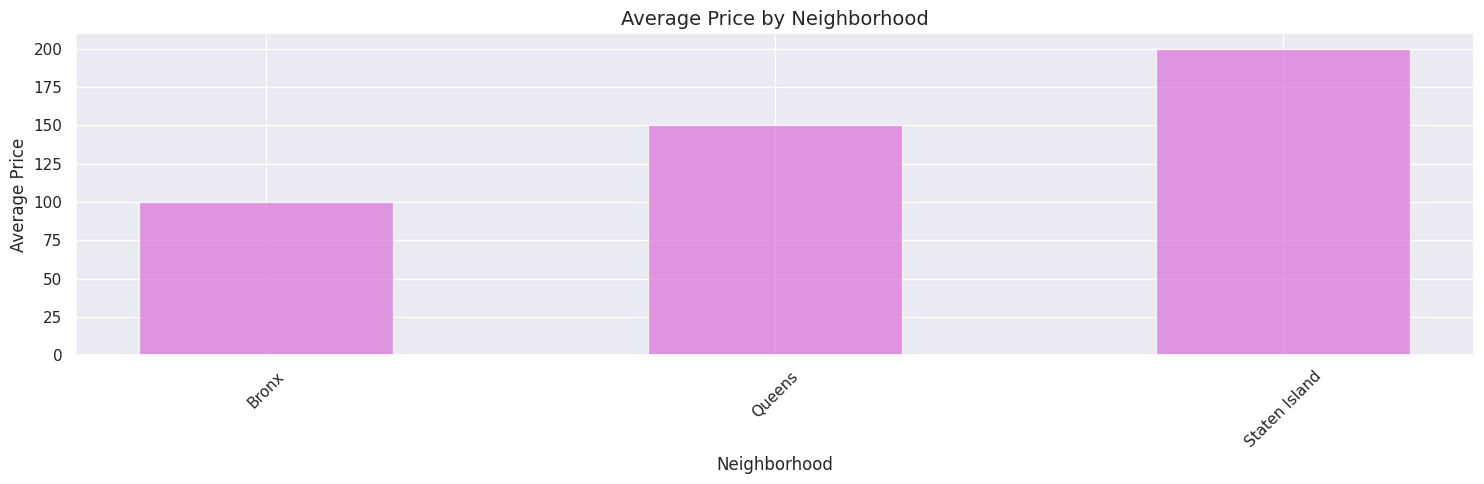

In [32]:
import matplotlib.pyplot as plt

# Assuming you have 'neighbourhood_avg_price_sorted_with_group' DataFrame
# and it contains columns 'neighbourhood' and 'avg_price'
# Create a sample DataFrame for demonstration purposes
neighbourhood_avg_price_sorted_with_group = pd.DataFrame({
    'neighbourhood': ['Neighborhood A', 'Neighborhood B', 'Neighborhood C'],
    'avg_price': [100, 150, 200]
})

neighborhoods = neighbourhood_avg_price_sorted_with_group['neighbourhood']
prices = neighbourhood_avg_price_sorted_with_group['avg_price']

# Map the original neighborhoods to desired borough names
borough_mapping = {
    'Neighborhood A': 'Bronx',
    'Neighborhood B': 'Queens',
    'Neighborhood C': 'Staten Island'
}

# Replace original neighborhood names with borough names
mapped_neighborhoods = [borough_mapping.get(neighborhood, neighborhood) for neighborhood in neighborhoods]

# Set the figure size to control the dimensions of the plot
plt.figure(figsize=(15, 5))

# Plotting the bar chart with mapped neighborhood names
plt.bar(mapped_neighborhoods, prices, width=0.5, color='orchid', alpha=0.7)  # Adjust width and color

# Adding labels and title
plt.xlabel('Neighborhood', fontsize=12)  # Label for x-axis
plt.ylabel('Average Price', fontsize=12)  # Label for y-axis
plt.title('Average Price by Neighborhood', fontsize=14)  # Title of the plot

# Rotating x-axis labels for better readability (optional)
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

* The neighborhoods listed are situated in the outer boroughs of New York City, such as the Bronx, Queens, and Staten Island. This indicates that they likely offer a more affordable cost of living compared to areas in Manhattan and Brooklyn.

* Primarily concentrated in the Bronx and Staten Island, these neighborhoods are known for their comparatively lower overall cost of living, making them appealing options for individuals seeking more budget-friendly housing in the New York City region

**(4) Price Distribution Of Each Neighborhood Group**

*   Price distribution is very high in Manhattan and Brooklyn. but Manhattan have more Diversity in price range, you can see in violin plot.

*   Queens and Bronx have same price distribution but in Queens area more distribution in **50 to 100 dollars** but diversity in price is not like Manhattan and Brooklyn.

**(5) Top Neighborhoods by Listing/property using Bar plot**

In [33]:
Top_Neighborhoods = data['neighbourhood'].value_counts()[:10].reset_index()
Top_Neighborhoods.columns = ['Top_Neighborhoods', 'Listing_Counts']
Top_Neighborhoods

,Top_Neighborhoods,Listing_Counts
0,Williamsburg,3732
1,Bedford-Stuyvesant,3638
2,Harlem,2585
3,Bushwick,2438
4,Upper West Side,1788
5,Hell's Kitchen,1731
6,East Village,1714
7,Upper East Side,1670
8,Crown Heights,1519
9,Midtown,1143


Text(0.5, 1.0, 'Listings by Top Neighborhoods in NYC')

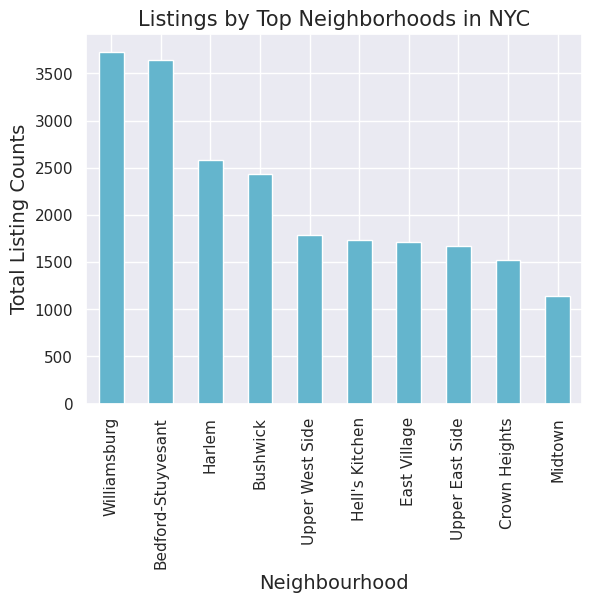

In [34]:
top_10_neigbourhoods = data['neighbourhood'].value_counts().nlargest(10)
top_10_neigbourhoods.plot(kind='bar', color='c')
plt.xlabel('Neighbourhood', fontsize=14)
plt.ylabel('Total Listing Counts', fontsize=14)
plt.title('Listings by Top Neighborhoods in NYC', fontsize=15)

1. The most popular neighborhoods for finding places to live in New York City are Williamsburg, Bedford-Stuyvesant, Harlem, Bushwick, and the Upper West Side.

2. These neighborhoods are mostly in Brooklyn and Manhattan. More people live in these areas, so more people are looking for homes there.

3. Just because there are lots of listings in a neighborhood doesn't mean everyone wants to live there. Other things, like how expensive it is to live there and how many homes are available, also matter.

**(6) Top Hosts With More Listing/Property using Bar chart**

In [35]:
top_10_hosts = data['host_name'].value_counts()[:10].reset_index()
top_10_hosts.columns = ['host_name', 'Total_listings']
top_10_hosts

,host_name,Total_listings
0,Michael,383
1,David,368
2,John,276
3,Sonder (NYC),272
4,Alex,253
5,Sarah,221
6,Daniel,212
7,Maria,197
8,Jessica,185
9,Mike,184


Text(0.5, 1.0, 'top 10 hosts on the basis of no of listings in entire NYC!')

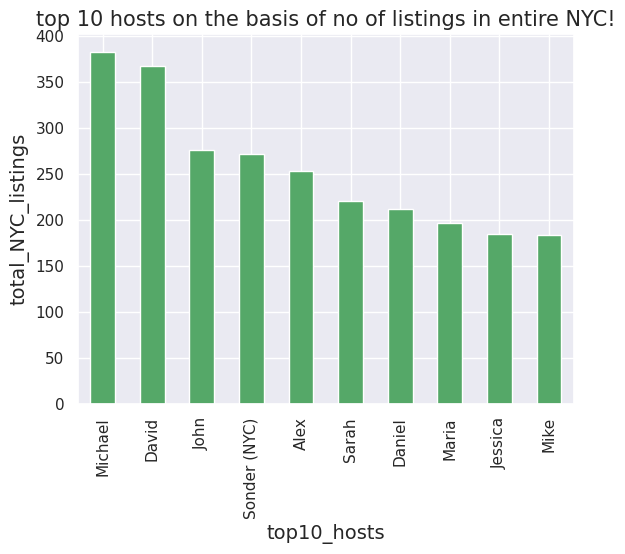

In [36]:
top_hosts =data['host_name'].value_counts()[:10]
top_hosts.plot(kind='bar', color='g')
plt.xlabel('top10_hosts', fontsize=14)
plt.ylabel('total_NYC_listings', fontsize=14)
plt.title('top 10 hosts on the basis of no of listings in entire NYC!', fontsize=15)

1. The top three hosts with the most listings are Michael, David, and John. Michael has 383 listings, David has 368, and John has 276.

2. Michael and David have a lot more listings than the others, like John, who has way fewer listings at 276.

3. Even in the top 10 list, Mike has 184 listings, which is way less than Michael's 383. This shows that some hosts are way more successful than others on Airbnb.

4. Not many hosts have a ton of listings. This suggests that Airbnb is pretty competitive, with just a few hosts dominating most of the market.

**(7) Number Of Active Hosts Per Location Using Line Chart**

In [37]:
hosts_per_location = data.groupby('neighbourhood_group')['listing_id'].count().reset_index()
hosts_per_location.columns = ['Neighbourhood_Groups', 'Host_counts']
hosts_per_location

,Neighbourhood_Groups,Host_counts
0,Bronx,1070
1,Brooklyn,19415
2,Manhattan,19501
3,Queens,5567
4,Staten Island,365


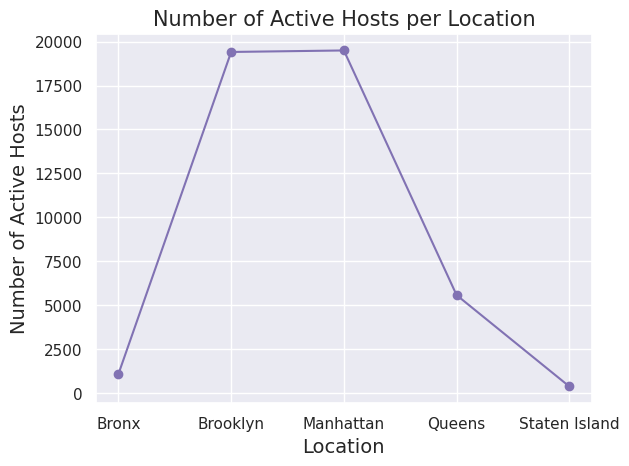

In [38]:
hosts_per_location = data.groupby('neighbourhood_group')['listing_id'].count()
locations = hosts_per_location.index
host_counts = hosts_per_location.values
plt.plot(locations, host_counts, marker='o', color='m')
plt.title('Number of Active Hosts per Location', fontsize='15')
plt.xlabel('Location', fontsize='14')
plt.ylabel('Number of Active Hosts', fontsize='14')
plt.show()

1. Manhattan has the most hosts, with 19,501. Brooklyn comes next with 19,415 hosts.
2. After them, Queens has 5,567 hosts, and the Bronx has 1,070. Staten Island has the least with 365 hosts.
3. Brooklyn and Manhattan have a lot of hosts, more than twice as many as Queens, and much more than the Bronx, which has very few.

**(8) Total Counts Of Each Room Type**

In [39]:
top_room_type = data['room_type'].value_counts().reset_index()
top_room_type.columns = ['Room_Type', 'Total_counts']
top_room_type

,Room_Type,Total_counts
0,Entire home/apt,22784
1,Private room,21996
2,Shared room,1138


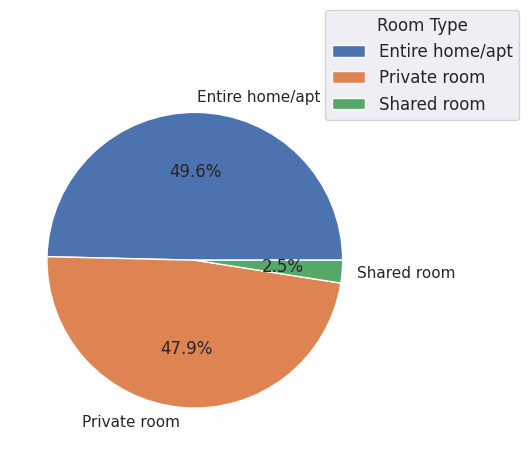

In [40]:
room_type_counts = data['room_type'].value_counts()
labels = room_type_counts.index
sizes = room_type_counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.legend(title='Room Type', bbox_to_anchor=(0.9, 0.2, 0.5, 1), fontsize='12')
plt.show()

* Most of the places you can rent on Airbnb are entire homes or apartments, with about 22,784 listings. Next, there are private rooms with about 21,996 listings, and shared rooms have the least, with only 1,138 listings.

* There's a big difference in how many places there are for each type of room. For example, there are almost 20 times more entire homes or apartments available compared to shared rooms.

* This shows that people who use Airbnb have lots of different types of places they can stay in, like private rooms or whole apartments.

**(9) Stay Requirement counts by Minimum Nights using Bar chart**

In [41]:
min_nights_count =data.groupby('minimum_nights').size().reset_index(name = 'count')
min_nights_count = min_nights_count.sort_values('count', ascending=False)
min_nights_count = min_nights_count.head(15)
min_nights_count = min_nights_count.reset_index(drop=True)
min_nights_count

,minimum_nights,count
0,1,12067
1,2,11080
2,3,7375
3,30,3489
4,4,3066
5,5,2821
6,7,1951
7,6,679
8,14,539
9,10,462


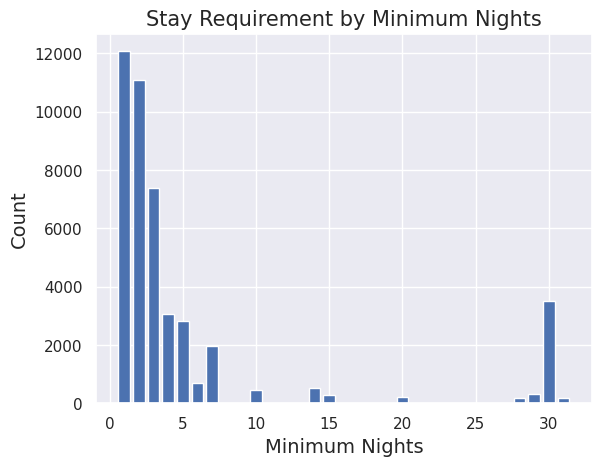

In [42]:
minimum_nights = min_nights_count['minimum_nights']
count = min_nights_count['count']
plt.bar(minimum_nights, count)
plt.xlabel('Minimum Nights', fontsize='14')
plt.ylabel('Count', fontsize='14')
plt.title('Stay Requirement by Minimum Nights', fontsize='15')
plt.show()

* Most Airbnb places let you stay for just 1 or 2 nights. There are lots of places like this, with over 12,000 listings for 1 night and over 11,000 for 2 nights.

* But if you want to stay longer, like for 3 nights or more, there are fewer options. For example, only about 7,000 listings need a minimum of 3 nights.

* And if you're planning a really long stay, like a month or more, there are even fewer choices. There are only around 3,500 listings for 30 nights or more, and even fewer, just 189, for 60 nights or more."

**(10) Total Reviews by Each Neighborhood Group using Pie Chart**

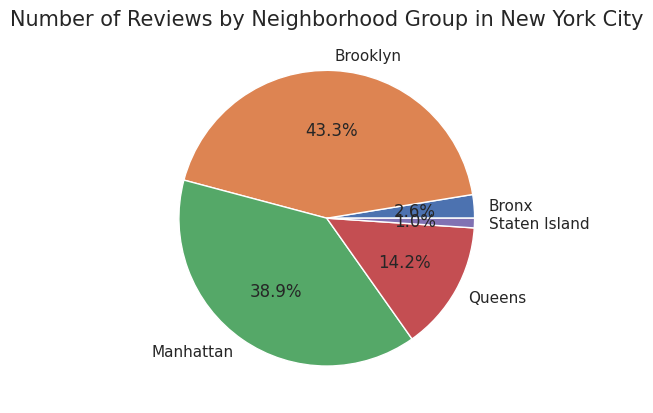

In [43]:
reviews_by_neighbourhood_group = data.groupby("neighbourhood_group")["total_reviews"].sum()
plt.pie(reviews_by_neighbourhood_group, labels=reviews_by_neighbourhood_group.index, autopct='%1.1f%%')
plt.title("Number of Reviews by Neighborhood Group in New York City", fontsize='15')
plt.show()

1. Brooklyn has the most reviews on Airbnb, with 43.3%, followed by Manhattan with 38.9%.

2. After Brooklyn and Manhattan, Queens has the next most reviews, with 14.2%, followed by the Bronx with 2.6% and Staten Island with 1.0%.

3. This data shows that people like using Airbnb more in Brooklyn and Manhattan compared to other areas.

4. Even though there are fewer places to stay listed in Brooklyn, it gets more reviews on Airbnb than Manhattan. This might mean that people who stay in Brooklyn are more likely to write reviews, or that the places in Brooklyn are really liked by guests. There could be other reasons too, like how good the places are or the type of people who use Airbnb in these areas.

**(11)Count Of Each Room Types In Entire NYC Using Multiple Bar Plot**

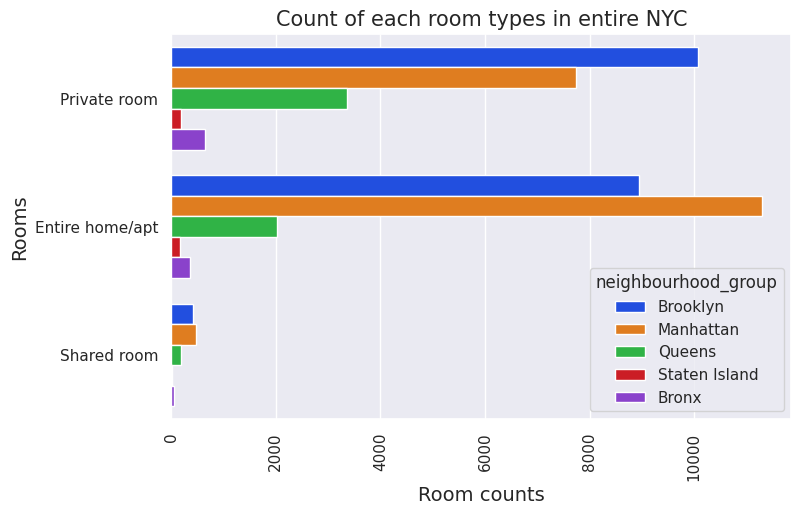

In [44]:
plt.rcParams['figure.figsize'] = (8, 5)
ax = sns.countplot(y='room_type',hue='neighbourhood_group', data=data, palette='bright')
plt.title('Count of each room types in entire NYC', fontsize='15')
plt.xlabel('Room counts', fontsize='14')
plt.xticks(rotation=90)
plt.ylabel('Rooms', fontsize='14')
plt.show()

* In New York City, Manhattan has the most entire homes or apartments listed on Airbnb, making up about 24.6% of all listings. Brooklyn comes next with around 19.5%.

* If we're talking about private rooms, Brooklyn has the most, making up 21.9% of all listings. Manhattan follows with 16.9%, and Queens has 7.3%.

* Not many places offer shared rooms on Airbnb. It's very rare to find them in Staten Island and the Bronx.

* To sum up, Brooklyn, Queens, and the Bronx have more private rooms available, while Manhattan, which has the most listings overall, offers more entire homes or apartments.

**(12) Use latitude and longitude in scatterplot map and find neighbourhood_groups and Room types in map**

Text(0.5, 1.0, 'Location Co-ordinates')

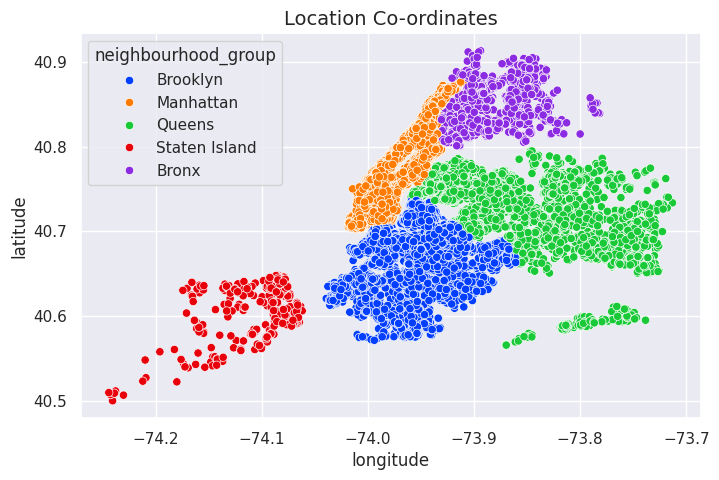

In [45]:
ax=sns.scatterplot(data=data, x="longitude", y="latitude", hue='neighbourhood_group', palette='bright')
ax.set_title('Location Co-ordinates', fontsize='14')

Text(0.5, 1.0, 'Distribution of type of rooms across NYC')

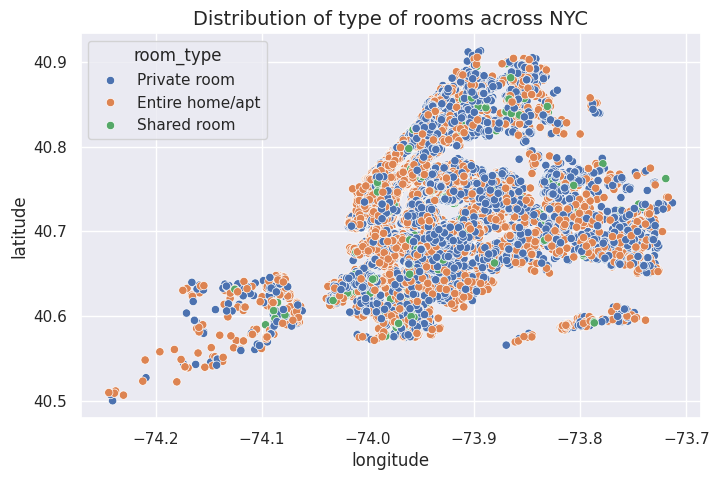

In [46]:
ax = sns.scatterplot(x=data.longitude, y=data.latitude, hue=data.room_type)
ax.set_title('Distribution of type of rooms across NYC', fontsize='14')

**(13) Price variations in NYC Neighbourhood groups using scatter plot**

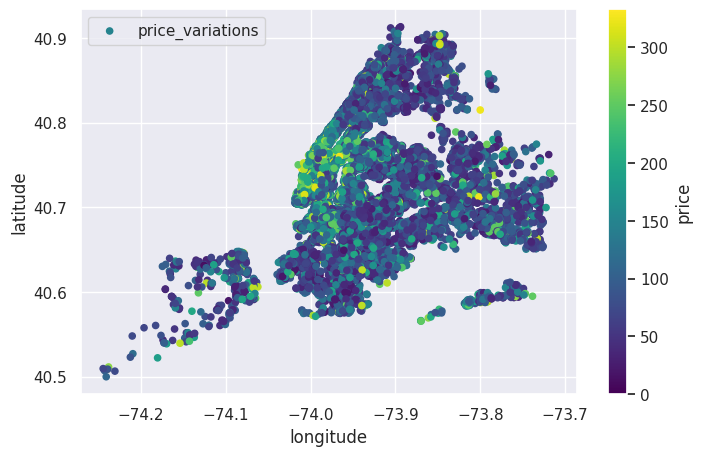

In [47]:
lat_long = data.plot(kind='scatter', x='longitude', y='latitude', label='price_variations', c='price', cmap='viridis', colorbar=True)

1. Accommodation prices in Manhattan are really expensive because it's got a lot of great stuff to offer, like in the picture.
   
2. Lots of tourists come here because there are so many cool things to see, which is why prices are higher compared to other neighborhoods.

3. People tend to stay longer in Manhattan because there are so many fun things to do, lots of cool places to visit, and it's easy to get around with public transportation.

**(14) Find Best Location Listing/Property Location For Travelers and Hosts**

<Axes: title={'center': 'Average Airbnb Reviews by Neighborhoods in New York City'}, xlabel='longitude', ylabel='latitude'>

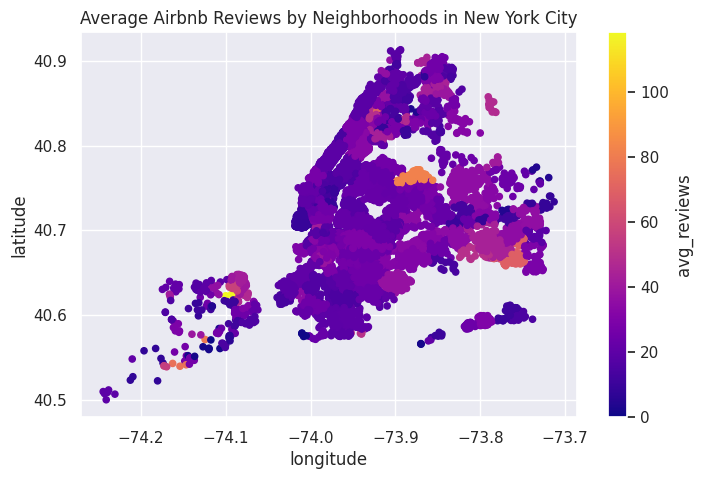

In [48]:
neighbourhood_avg_reviews = data.groupby("neighbourhood")["total_reviews"].mean()
neighbourhood_reviews = pd.DataFrame({"neighbourhood": neighbourhood_avg_reviews.index, "avg_reviews": neighbourhood_avg_reviews.values})
df = data.merge(neighbourhood_reviews, on="neighbourhood")
fig = df.plot.scatter(x="longitude", y="latitude", c="avg_reviews", title="Average Airbnb Reviews by Neighborhoods in New York City", cmap="plasma")
fig


* The neighborhoods close to the airport in Queens probably get more reviews because many tourists and travelers stay there. Being near the airport makes it easy for people coming in or passing through to choose these areas. Also, these neighborhoods might have lots of great places to stay or things to do, which attract more visitors and get more reviews. So, the airport being nearby is likely a big reason for the high number of reviews."

**(15) Pair Plot Visualization**

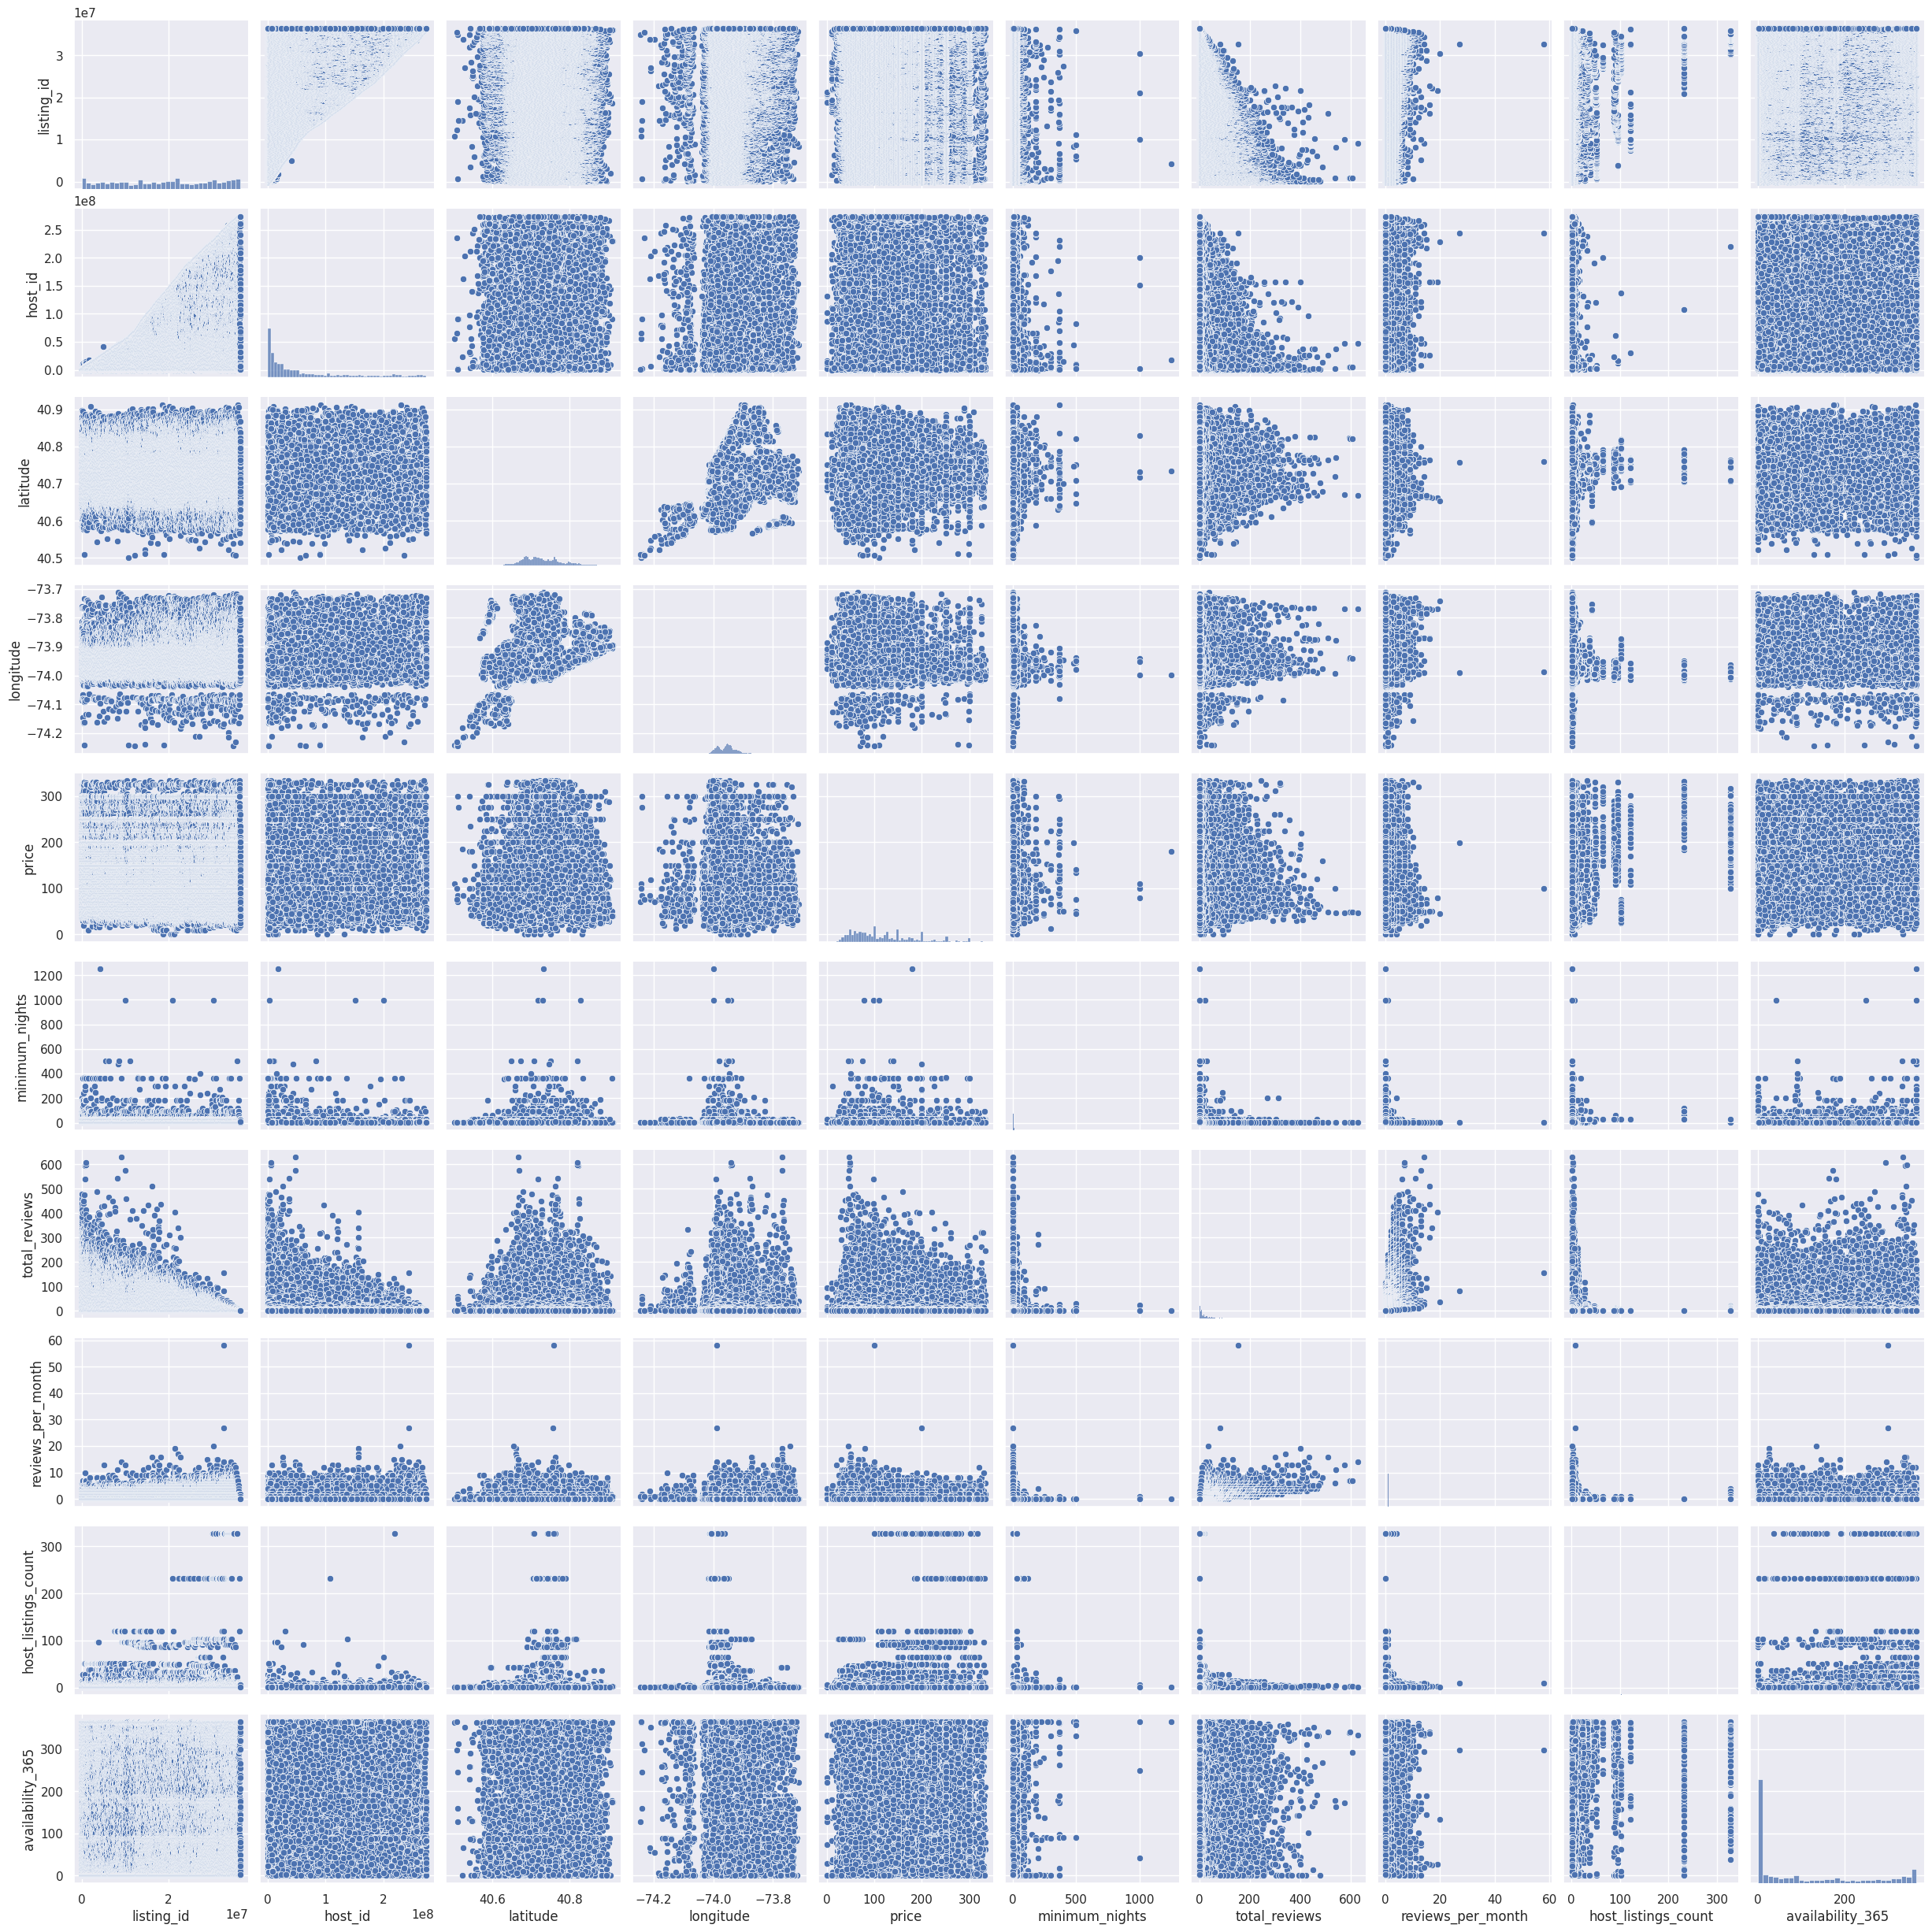

In [49]:
sns.pairplot(data)

*   A pair plot consists of multiple scatterplots arranged in a grid, with each
scatterplot showing the relationship between two variables

*   It can be used to visualize relationships between multiple variables and to identify patterns in the data.

In [50]:
def Encode(data):
    for column in data.columns[data.columns.isin(['neighbourhood_group', 'room_type'])]:
        data[column] = data[column].factorize()[0]
    return data


In [51]:
data.head(15)

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,reviews_per_month,host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,3,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,0,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,1,4,188


In [52]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.0 MB/s eta 0:00:00


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import category_encoders as ce # This line imports the category_encoders library, which was causing the error because it wasn't installed. Installing it with !pip install category_encoders should resolve the issue.

# Filter the data
data = data[(data['price'] > 0) & (data['availability_365'] > 0)]

# Define features and target
X = data[['neighbourhood_group', 'neighbourhood', 'room_type', 'minimum_nights', 'reviews_per_month', 'availability_365']]
y = np.log10(data['price'])

# Create a OneHotEncoder instance
encoder = ce.OneHotEncoder(handle_unknown='ignore', use_cat_names=True)

# Fit the encoder on the categorical features and transform them
X_encoded = encoder.fit_transform(X[['neighbourhood_group', 'neighbourhood', 'room_type']])

# Concatenate the encoded features with the numerical features
X_processed = pd.concat([X_encoded, X[['minimum_nights', 'reviews_per_month', 'availability_365']]], axis=1)


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=101)

# Create and train the model
lm = LinearRegression()
lm.fit(X_train, y_train)

# Make predictions
y_pred = lm.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"""
      Mean Squared Error: {rmse}
      R2 Score: {r2 * 100}
      Mean Absolute Error: {mae}
     """)


      Mean Squared Error: 0.16068595708306974
      R2 Score: 59.80272492529578
      Mean Absolute Error: 0.12587724527465072
     


In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

new_data = {
    'neighbourhood_group': 'Manhattan',
    'neighbourhood': 'Upper West Side',
    'room_type': 'Entire home/apt',
    'minimum_nights': 2,
    'reviews_per_month': 1.5,
    'availability_365': 200
}

input_df = pd.DataFrame([new_data])



data = data[(data['price'] > 0) & (data['availability_365'] > 0)]

X = data[['neighbourhood_group', 'neighbourhood', 'room_type', 'minimum_nights', 'reviews_per_month', 'availability_365']]
y = np.log10(data['price'])

X_encoded = encoder.transform(X[['neighbourhood_group', 'neighbourhood', 'room_type']])

X_processed = np.hstack((X_encoded, X[['minimum_nights', 'reviews_per_month', 'availability_365']].values))

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=101)

lm = LinearRegression()
lm.fit(X_train, y_train)

input_encoded = encoder.transform(input_df[['neighbourhood_group', 'neighbourhood', 'room_type']])
input_processed = np.hstack((input_encoded, input_df[['minimum_nights', 'reviews_per_month', 'availability_365']].values))

predicted_log_price = lm.predict(input_processed)

predicted_price = 10**predicted_log_price

print("Predicted Price:", predicted_price)


Predicted Price: [186.76167186]


In [56]:
import pandas as pd

print("Column Names:", data.columns)

numeric_columns = [
    'price', 'minimum_nights', 'reviews_per_month', 'availability_365'
]

numeric_data = data[numeric_columns]

correlation_matrix = numeric_data.corr()

print("Correlation Matrix:")
print(correlation_matrix)


Column Names: Index(['listing_id', 'listing_name', 'host_id', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'total_reviews',
       'reviews_per_month', 'host_listings_count', 'availability_365'],
      dtype='object')
Correlation Matrix:
                      price  minimum_nights  reviews_per_month  \
price              1.000000        0.036706          -0.074144   
minimum_nights     0.036706        1.000000          -0.167657   
reviews_per_month -0.074144       -0.167657           1.000000   
availability_365   0.042860        0.125656          -0.075189   

                   availability_365  
price                      0.042860  
minimum_nights             0.125656  
reviews_per_month         -0.075189  
availability_365           1.000000  


In [59]:
# prompt: SAVE LR

import pickle

# Assuming 'lm' is your trained linear regression model and 'encoder' is your fitted OneHotEncoder
filename = 'finalized_model.sav'
pickle.dump(lm, open(filename, 'wb'))

filename = 'finalized_encoder.sav'
pickle.dump(encoder, open(filename, 'wb'))


In [60]:
# prompt: LOAD MODEL\

# Load the saved model
loaded_model = pickle.load(open('finalized_model.sav', 'rb'))

# Load the saved encoder
loaded_encoder = pickle.load(open('finalized_encoder.sav', 'rb'))


In [61]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

LinearRegression()

# Business Conclusion

1. **Manhattan and Brooklyn are super popular for Airbnb rentals.** Lots of people list their places there, making it a good investment for hosts.

2. **Manhattan is famous for its parks, museums, and landmarks, so lots of tourists go there, driving up demand and prices.**

3. **Brooklyn is also popular, especially in neighborhoods like Williamsburg and Bedford-Stuyvesant. It's cheaper than Manhattan, but still gets a lot of visitors.**

4. **Neighborhoods like Williamsburg, Bedford-Stuyvesant, Harlem, Bushwick, and the Upper West Side have a ton of Airbnb listings, showing they're in high demand.**

5. **In Manhattan, prices are higher because it's the center, but there's also more competition among hosts.**

6. **Most Airbnb listings are for short stays, so hosts might want to focus on places that can accommodate shorter visits to keep their spaces busy.**

7. **Most listings are for entire homes or private rooms, giving travelers plenty of choices. Hosts might want to consider properties that can fit more guests.**

8. **The number of Airbnb rentals varies a lot by neighborhood. Some areas have tons of options, while others have fewer.**

9. **Competition among hosts is fierce, with some dominating the market. Hosts might do better in areas with fewer listings.**

10. **Neighborhoods near airports in Queens might have more reviews because they attract lots of travelers. Being close to the airport can also mean cheaper stays compared to Manhattan and Brooklyn.**